# Sensitivity to volatility-cluster resolution

This supplementary notebook asks whether the chosen volatility resolution changes inference or predictions. A single amortized estimator is trained across $d\in\{128,64,32,16,8,4\}$ terminal cascade blocks, corresponding to block lengths from 2 to 64 trading days. Recovery is checked at every resolution; the fitted models are then compared on the same turbulent COVID-era window used in `mmar_motivation`.

In [1]:
from pathlib import Path

import bayesflow as bf

from mmar import sensitivity as model, viz
from mmar.data import load_market_returns
from mmar.viz import sensitivity as plots

D_VALUES = model.CLUSTER_COUNTS
TICKERS = ("VOO", "SPMO")
COVID_WINDOW_END = "2021-01-07"
FIGURES_DIR = Path("figures/sensitivity")
CHECKPOINT_DIR = Path("checkpoints/sensitivity")

viz.configure_plot_style()

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## 1. Simulator and conditioning

$$r_t=\mu+\bar\sigma\sqrt{\theta_t(q,d)}\varepsilon_t,\qquad \varepsilon_t=z_t\sqrt{(\nu-2)/U_t},$$

$$z_t\sim N(0,1),\qquad U_t\sim\chi^2_\nu.$$

This is the univariate MMAR from the first notebook, with one explicit design choice added: $d$ is the number of terminal cascade blocks, so each block spans $256/d$ days. The network targets $p(\mu,\bar\sigma,q,\nu\mid r_{1:256},\log d)$; $d$ is known and passed through `inference_conditions`, not inferred.

In [2]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .constrain("sigma_bar", lower=model.PRIOR.sigma_low, upper=model.PRIOR.sigma_high)
    .constrain("q", lower=model.PRIOR.q_low, upper=model.PRIOR.q_high)
    .constrain("nu", lower=model.PRIOR.nu_low, upper=model.PRIOR.nu_high)
    .concatenate(model.PARAMETER_NAMES, into="inference_variables")
    .rename("log_d", "inference_conditions")
    .as_time_series("returns")
    .rename("returns", "summary_variables")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.FusionTransformer(dropout=0.1),
    inference_network=bf.networks.CouplingFlow(transform="spline", depth=4),
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.


## 2. Amortized training

In [3]:
training_simulations = model.simulate(100_000)
validation_simulations = model.simulate(600)

In [4]:
history = workflow.fit_offline(
    data=training_simulations, validation_data=validation_simulations, epochs=100, batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - loss: 4.6763 - val_loss: 3.3359
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - loss: 2.8103 - val_loss: 2.6007
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - loss: 2.1977 - val_loss: 1.7743
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 2.0161 - val_loss: 1.7601
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.9079 - val_loss: 1.6656
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.7763 - val_loss: 1.4609
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.6450 - val_loss: 1.3362
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.5437 - val_loss: 1.3414
Epoch 9/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.4745 - val_loss: 1.2395
Epoch 10/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 1.4347 - val_loss: 1.1190
Epoch 11/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - loss: 1.3480 - val_loss: 1.0347
Epoch 12/100
782/78

INFO:bayesflow:Training completed in 44.32 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/sensitivity/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/sensitivity/model.keras")


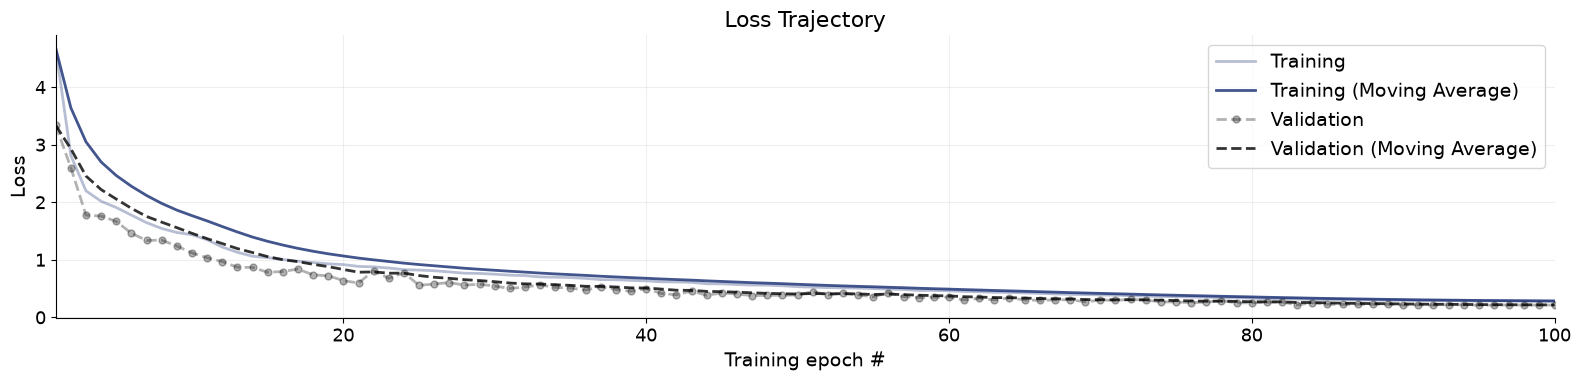

In [5]:
fig = bf.diagnostics.loss(history)

## 3. Parameter recovery by clustering resolution $d$

In [6]:
workflow.load_approximator()

INFO:bayesflow:Approximator restored from 'checkpoints/sensitivity/model.keras'.


Summarizing:   0%|          | 0/2 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/2 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 8.39 seconds.


Summarizing:   0%|          | 0/2 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/2 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/2 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.13 seconds.


Summarizing:   0%|          | 0/2 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/2 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.14 seconds.


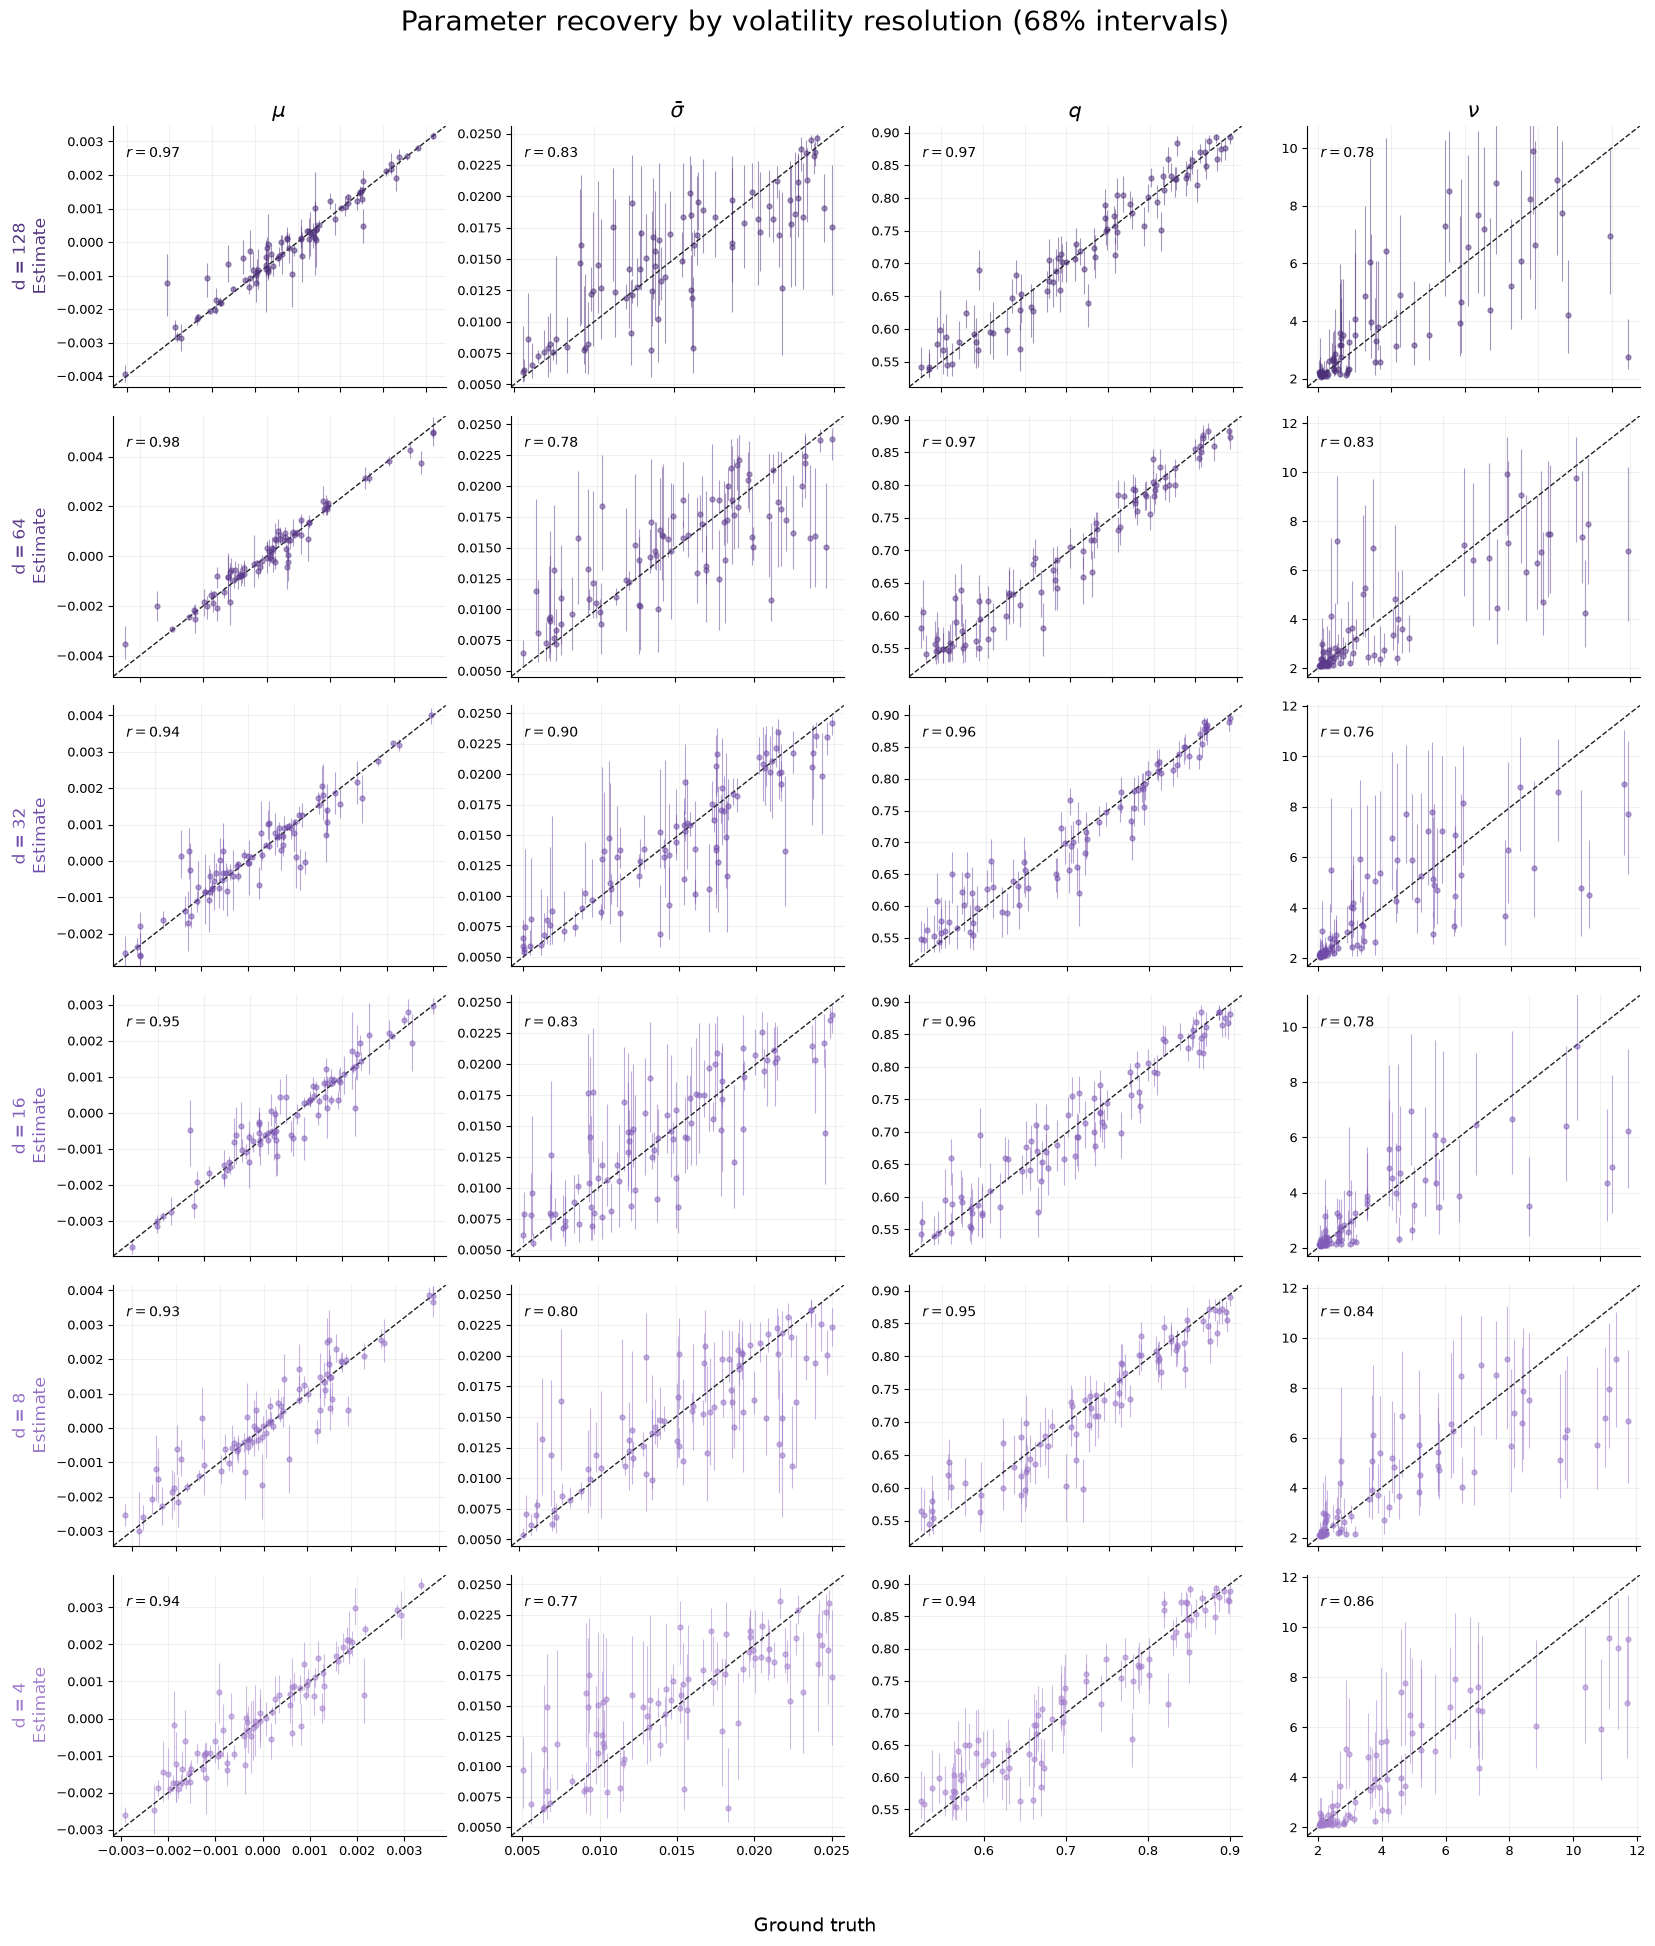

In [7]:
recovery = model.recovery_samples(workflow, n_test=80, num_samples=256)
fig = plots.plot_recovery_grid(recovery, model.PARAMETER_LABELS)
_ = viz.save_figure(fig, "01_parameter_recovery_by_d.png", FIGURES_DIR)

## 4. COVID-window posterior predictions

We will use the 256 trading days ending on 2021-01-07, exactly the COVID-era period selected in [`mmar_motivation`](./mmar_motivation.ipynb). For each ETF, the same observations are conditioned on at every fixed $d$; only the assumed cascade resolution changes. Thus, posterior-predictive wealth bands isolate the practical effect of $d$.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 7.36 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.08 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.09 seconds.


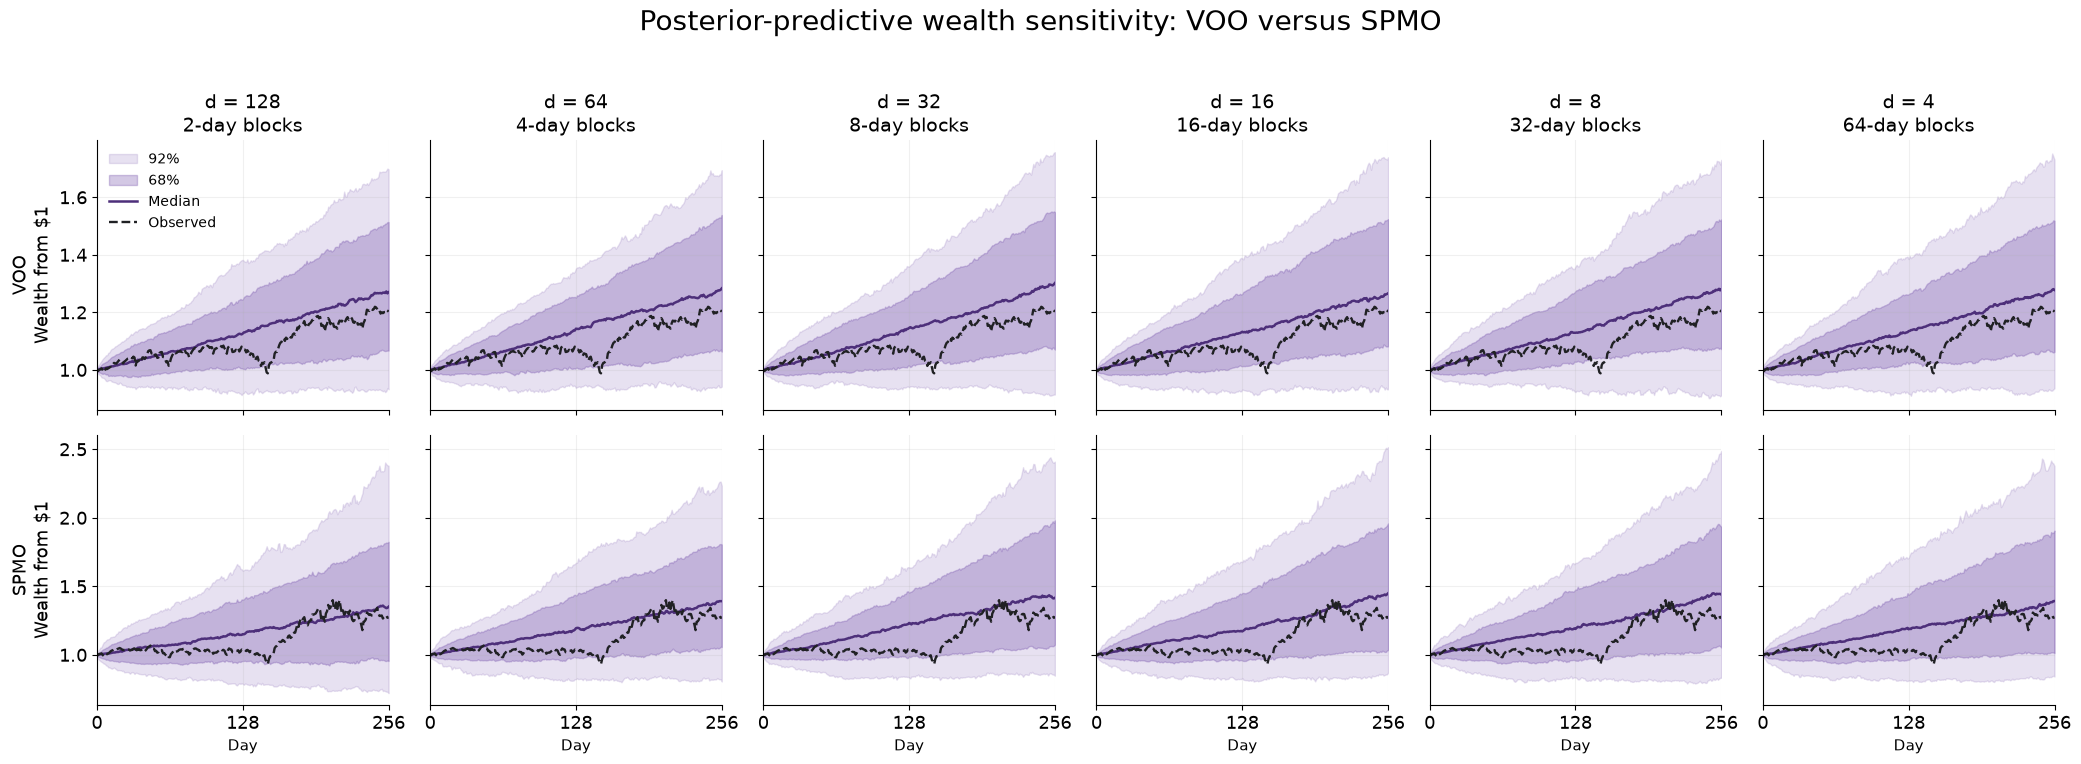

In [ ]:
market = load_market_returns(
    ("SPMO", "VOO"), start="2020-01-01", end="2026-09-01"
).loc[:COVID_WINDOW_END, list(TICKERS)].tail(model.WINDOW)

observed = market.to_numpy().T

sensitivity = model.posterior_predictive_analysis(
    workflow, observed, num_samples=1_000, seed=200
)
predictive_wealth = sensitivity["wealth"]

fig = plots.plot_wealth_grid(
    predictive_wealth, observed, TICKERS, D_VALUES,
    figure_title=(
        "COVID-window posterior-predictive wealth sensitivity "
        f"({market.index[0].date()} to {market.index[-1].date()})"
    ),
)
_ = viz.save_figure(fig, "02_wealth_sensitivity.png", FIGURES_DIR)

## 5. Quantifying the impact of $d$

For any posterior or predictive quantity $Y$, we can define the resolution-sensitivity ratio

$$S_Y=\frac{\max_d\operatorname{median}(Y\mid d)-\min_d\operatorname{median}(Y\mid d)}{\operatorname{median}_d\left[Q_{0.96}(Y\mid d)-Q_{0.04}(Y\mid d)\right]}.$$

The numerator is the full shift caused by changing $d$; the denominator is a typical 92% uncertainty width. Thus $S_Y\ll1$ means the choice of resolution has little impact relative to uncertainty, whereas $S_Y\gtrsim1$ signals a resolution-dependent shift. We report both the raw median spread and this scale-free ratio.

In [ ]:
sensitivity_summary = model.resolution_sensitivity_summary(
    sensitivity["parameters"], predictive_wealth, TICKERS, D_VALUES
)
sensitivity_summary.index.name = (
    f"ETF ({market.index[0].date()} to {market.index[-1].date()})"
)
sensitivity_summary.style.format(
    {
        "$q$ median, $d=128$": "{:.3f}",
        "$q$ median, $d=4$": "{:.3f}",
        r"$\Delta_d q$ (coarse $-$ fine)": "{:+.3f}",
        r"$S_q$": "{:.2f}",
        r"$\Delta_d$ terminal return (pp)": "{:.1f}",
        r"$S_{R_T}$": "{:.2f}",
        r"$\Delta_d$ max drawdown (pp)": "{:.1f}",
        r"$S_{\mathrm{MDD}}$": "{:.2f}",
    }
)

ETF (2020-01-03 to 2021-01-07),"$q$ median, $d=128$","$q$ median, $d=4$",$\Delta_d q$ (coarse $-$ fine),$S_q$,$\Delta_d$ terminal return (pp),$S_{R_T}$,$\Delta_d$ max drawdown (pp),$S_{\mathrm{MDD}}$
VOO,0.747,0.860,+0.113,1.69,8.9,0.04,1.8,0.05
SPMO,0.738,0.852,+0.114,1.71,5.3,0.02,0.3,0.01


The conclusion is sharp: $d$ materially changes the interpretation of $q$, but barely changes the predictive answer. Coarsening the cascade from $d=128$ (2-day blocks) to $d=4$ (64-day blocks) raises the posterior median of $q$ by about $0.11$ for both ETFs, and $S_q\approx1.7$ means that shift exceeds a typical 92% posterior width. The coarser tree needs a more unequal split to reproduce the same observed clustering.

In contrast, the terminal-return and maximum-drawdown ratios remain below $0.06$: their across-$d$ median shifts are small relative to their 92% predictive widths. For this COVID window, $q$ and $d$ compensate for one another, so $q$ is resolution-dependent while the posterior-predictive wealth and drawdown conclusions are robust.